In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


### Data Loading and Exploration
The Elliptic dataset contains Bitcoin transactions represented as a graph. We load the node features, the edge list (transactions flows), and the target classes.

In [2]:
import pandas as pd
import numpy as np
import os

data_dir = '/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/'

df_features = pd.read_csv(os.path.join(data_dir, 'elliptic_txs_features.csv'), header=None)
df_edges = pd.read_csv(os.path.join(data_dir, 'elliptic_txs_edgelist.csv'))
df_classes = pd.read_csv(os.path.join(data_dir, 'elliptic_txs_classes.csv'))

print(f"Nodes: {df_features.shape}")
print(f"Edges: {df_edges.shape}")

Nodes: (203769, 167)
Edges: (234355, 2)


### Class Distribution
We have a massive class imbalance. Out of ~200k nodes, over 150k are unlabeled ('unknown'). Among the labeled nodes, illicit transactions make up only roughly 10% of the data. We will need to handle this imbalance during training.

In [3]:
df_classes['class'].value_counts()

class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

### Graph Preprocessing
PyTorch Geometric requires contiguous integer IDs for nodes. The raw `txId` strings are mapped to sequential integers (0 to N-1). We also map the string labels to integers: 
* Licit: `0`
* Illicit: `1`
* Unknown: `-1` (We will mask these out during loss calculation).

In [4]:
class_mapping = {'1': 1, '2': 0, 'unknown': -1}
df_classes['label'] = df_classes['class'].map(class_mapping)

node_mapping = {tx_id: index for index, tx_id in enumerate(df_features[0].values)}

df_edges['source'] = df_edges['txId1'].map(node_mapping)
df_edges['target'] = df_edges['txId2'].map(node_mapping)
df_edges = df_edges.dropna(subset=['source', 'target'])

df_edges['source'] = df_edges['source'].astype(int)
df_edges['target'] = df_edges['target'].astype(int)

df_edges.head()

,txId1,txId2,source,target
0,230425980,5530458,0,1
1,232022460,232438397,2,3
2,230460314,230459870,4,5
3,230333930,230595899,6,7
4,232013274,232029206,8,9


In [5]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.0 MB/s eta 0:00:0000:01


### PyTorch Geometric Conversion
We construct the `Data` object. Crucially, this dataset requires a **temporal train/test split**. Transactions occur over 49 time steps. To simulate real-world conditions, we train on time steps 1-34 and test on time steps 35-49.

In [6]:
import torch
from torch_geometric.data import Data

time_steps = df_features[1].values
features = df_features.drop(columns=[0, 1]).values
x = torch.tensor(features, dtype=torch.float)

labels = df_classes['label'].values
y = torch.tensor(labels, dtype=torch.long)

edges = df_edges[['source', 'target']].values.T
edge_index = torch.tensor(edges, dtype=torch.long)

In [7]:
train_mask = (time_steps <= 34) & (labels != -1)
test_mask = (time_steps > 34) & (labels != -1)

data = Data(x=x, edge_index=edge_index, y=y)
data.train_mask = torch.tensor(train_mask, dtype=torch.bool)
data.test_mask = torch.tensor(test_mask, dtype=torch.bool)

data

Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])

### Model Architecture: Graph Convolutional Network (GCN)
We define a 2-layer GCN. Message passing allows each node to aggregate information from its immediate neighbors, creating embeddings that capture both the transaction's inherent features and its network topology.

In [8]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn

class FraudGCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes):
        super(FraudGCN, self).__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

### Reproducibility
Deep learning models rely on random weight initialization and stochastic operations like Dropout. To ensure our results are exactly reproducible across different runs, we lock the random seeds for PyTorch, NumPy, and Python's built-in random module.

In [9]:
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

### Training Configuration
To combat the 1:10 class imbalance, we apply class weights to the CrossEntropy loss function. Missing an illicit transaction incurs a 10x penalty compared to misclassifying a licit one.

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data = data.to(device)
model = FraudGCN(num_node_features=165, hidden_channels=64, num_classes=2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

class_weights = torch.tensor([1.0, 10.0], dtype=torch.float).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

In [11]:
def train():
    model.train()               
    optimizer.zero_grad()       
    out = model(data.x, data.edge_index)
    
    # Calculate loss exclusively on labeled training nodes
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    
    loss.backward()             
    optimizer.step()            
    return loss.item()

### Training Loop and Evaluation
We track the model's performance on the test set dynamically. Because our primary goal is fraud detection, we checkpoint the model based on the maximum F1-Score of the Illicit class.

In [12]:
from sklearn.metrics import classification_report

best_f1 = 0
best_epoch = 0

for epoch in range(1, 201):
    loss = train()
    
    if epoch % 20 == 0:
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            pred = out.argmax(dim=1)
            
            test_preds = pred[data.test_mask].cpu().numpy()
            test_labels = data.y[data.test_mask].cpu().numpy()
            
            report = classification_report(test_labels, test_preds, output_dict=True, zero_division=0)
            illicit_f1 = report['1']['f1-score']
            illicit_prec = report['1']['precision']
            illicit_rec = report['1']['recall']
            
            print(f'Epoch: {epoch:03d} | Loss: {loss:.4f} | Illicit -> Prec: {illicit_prec:.2f}, Rec: {illicit_rec:.2f}, F1: {illicit_f1:.2f}')
            
            if illicit_f1 > best_f1:
                best_f1 = illicit_f1
                best_epoch = epoch
                torch.save(model.state_dict(), 'best_fraud_gcn.pt')

print(f"\nBest model achieved an Illicit F1-Score of {best_f1:.4f} at Epoch {best_epoch}")

Epoch: 020 | Loss: 0.3304 | Illicit -> Prec: 0.13, Rec: 0.86, F1: 0.22
Epoch: 040 | Loss: 0.2678 | Illicit -> Prec: 0.18, Rec: 0.70, F1: 0.29
Epoch: 060 | Loss: 0.2346 | Illicit -> Prec: 0.24, Rec: 0.63, F1: 0.35
Epoch: 080 | Loss: 0.2182 | Illicit -> Prec: 0.30, Rec: 0.61, F1: 0.40
Epoch: 100 | Loss: 0.2037 | Illicit -> Prec: 0.30, Rec: 0.60, F1: 0.40
Epoch: 120 | Loss: 0.1909 | Illicit -> Prec: 0.33, Rec: 0.59, F1: 0.42
Epoch: 140 | Loss: 0.1775 | Illicit -> Prec: 0.32, Rec: 0.60, F1: 0.42
Epoch: 160 | Loss: 0.1732 | Illicit -> Prec: 0.36, Rec: 0.58, F1: 0.44
Epoch: 180 | Loss: 0.1698 | Illicit -> Prec: 0.38, Rec: 0.57, F1: 0.46
Epoch: 200 | Loss: 0.1608 | Illicit -> Prec: 0.36, Rec: 0.55, F1: 0.43

Best model achieved an Illicit F1-Score of 0.4582 at Epoch 180


In [13]:
model.eval()  # Put the model in evaluation mode (turns off dropout)
    
with torch.no_grad():  # Turn off gradient tracking to save memory/speed
    # Forward pass on the whole graph
    out = model(data.x, data.edge_index)
    
    # Get the predicted classes (the index with the highest probability)
    pred = out.argmax(dim=1)
    
    # Filter down to ONLY the test set nodes
    test_preds = pred[data.test_mask].cpu().numpy()
    test_labels = data.y[data.test_mask].cpu().numpy()
    
    print("\n--- Test Set Evaluation ---")
    # Generate the report
    print(classification_report(test_labels, test_preds, 
                                target_names=['Licit (0)', 'Illicit (1)']))


--- Test Set Evaluation ---
              precision    recall  f1-score   support

   Licit (0)       0.97      0.93      0.95     15587
 Illicit (1)       0.36      0.55      0.43      1083

    accuracy                           0.91     16670
   macro avg       0.66      0.74      0.69     16670
weighted avg       0.93      0.91      0.92     16670



### Upgrading to GraphSAGE
Our baseline GCN processes the entire graph matrix simultaneously. This is computationally expensive and scales poorly to new, unseen transactions. We upgrade to GraphSAGE (`SAGEConv`), which samples a fixed number of local neighbors to aggregate features, mimicking how production systems handle dynamic transaction networks.

In [14]:
from torch_geometric.nn import SAGEConv

class FraudSAGE(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes):
        super(FraudSAGE, self).__init__()
        self.conv1 = SAGEConv(num_node_features, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, num_classes)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

### GraphSAGE Training Loop
We initialize the new GraphSAGE architecture and run our 200-epoch training loop, tracking the F1-score of the illicit class for model selection.

In [15]:
sage_model = FraudSAGE(num_node_features=165, hidden_channels=64, num_classes=2).to(device)
optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=0.01, weight_decay=5e-4)


In [16]:
def train_sage():
    sage_model.train()               
    optimizer_sage.zero_grad()       
    out = sage_model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()             
    optimizer_sage.step()            
    return loss.item()

In [17]:
best_f1_sage = 0
best_epoch_sage = 0


for epoch in range(1, 201):
    loss = train_sage()
    
    if epoch % 20 == 0:
        sage_model.eval()
        with torch.no_grad():
            out = sage_model(data.x, data.edge_index)
            pred = out.argmax(dim=1)
            
            test_preds = pred[data.test_mask].cpu().numpy()
            test_labels = data.y[data.test_mask].cpu().numpy()
            
            report = classification_report(test_labels, test_preds, output_dict=True, zero_division=0)
            illicit_f1 = report['1']['f1-score']
            illicit_prec = report['1']['precision']
            illicit_rec = report['1']['recall']
            
            print(f'Epoch: {epoch:03d} | Loss: {loss:.4f} | Illicit -> Prec: {illicit_prec:.2f}, Rec: {illicit_rec:.2f}, F1: {illicit_f1:.2f}')
            
            if illicit_f1 > best_f1_sage:
                best_f1_sage = illicit_f1
                best_epoch_sage = epoch
                torch.save(sage_model.state_dict(), 'best_fraud_sage.pt')

print(f"\nBest GraphSAGE achieved an Illicit F1-Score of {best_f1_sage:.4f} at Epoch {best_epoch_sage}")

Epoch: 020 | Loss: 0.2087 | Illicit -> Prec: 0.17, Rec: 0.86, F1: 0.29
Epoch: 040 | Loss: 0.1487 | Illicit -> Prec: 0.29, Rec: 0.73, F1: 0.41
Epoch: 060 | Loss: 0.1219 | Illicit -> Prec: 0.36, Rec: 0.70, F1: 0.47
Epoch: 080 | Loss: 0.1019 | Illicit -> Prec: 0.41, Rec: 0.68, F1: 0.51
Epoch: 100 | Loss: 0.0927 | Illicit -> Prec: 0.48, Rec: 0.65, F1: 0.56
Epoch: 120 | Loss: 0.0835 | Illicit -> Prec: 0.48, Rec: 0.66, F1: 0.56
Epoch: 140 | Loss: 0.0785 | Illicit -> Prec: 0.47, Rec: 0.67, F1: 0.55
Epoch: 160 | Loss: 0.0757 | Illicit -> Prec: 0.51, Rec: 0.68, F1: 0.58
Epoch: 180 | Loss: 0.0732 | Illicit -> Prec: 0.50, Rec: 0.68, F1: 0.57
Epoch: 200 | Loss: 0.0704 | Illicit -> Prec: 0.55, Rec: 0.66, F1: 0.60

Best GraphSAGE achieved an Illicit F1-Score of 0.6027 at Epoch 200


### Final Model Evaluation
To evaluate our model, we must load the optimal weights saved during the training loop. We evaluate the test set using a classification report for standard metrics (Precision, Recall, F1) and a Confusion Matrix to quantify the exact number of false positives (false alarms) versus false negatives (missed fraud).

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

sage_model.load_state_dict(torch.load('best_fraud_sage.pt'))
sage_model.eval()

with torch.no_grad():
    out = sage_model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    
    test_preds = pred[data.test_mask].cpu().numpy()
    test_labels = data.y[data.test_mask].cpu().numpy()
    
    print(classification_report(test_labels, test_preds, target_names=['Licit (0)', 'Illicit (1)']))
    
    cm = confusion_matrix(test_labels, test_preds)
    print("Confusion Matrix:\n", cm)

              precision    recall  f1-score   support

   Licit (0)       0.98      0.96      0.97     15587
 Illicit (1)       0.55      0.66      0.60      1083

    accuracy                           0.94     16670
   macro avg       0.76      0.81      0.79     16670
weighted avg       0.95      0.94      0.95     16670

Confusion Matrix:
 [[15003   584]
 [  364   719]]


### Visualizing a Fraud Ring (High-Degree Subgraph)
To truly understand the topology of illicit transactions, we must isolate a highly connected subgraph. We calculate the degree of all nodes, identify the illicit node with the highest number of connections, and extract its 2-hop neighborhood. Treating the graph as undirected ensures we capture both incoming and outgoing transaction flows.

Targeting Illicit Node 148166 with 177 connections.


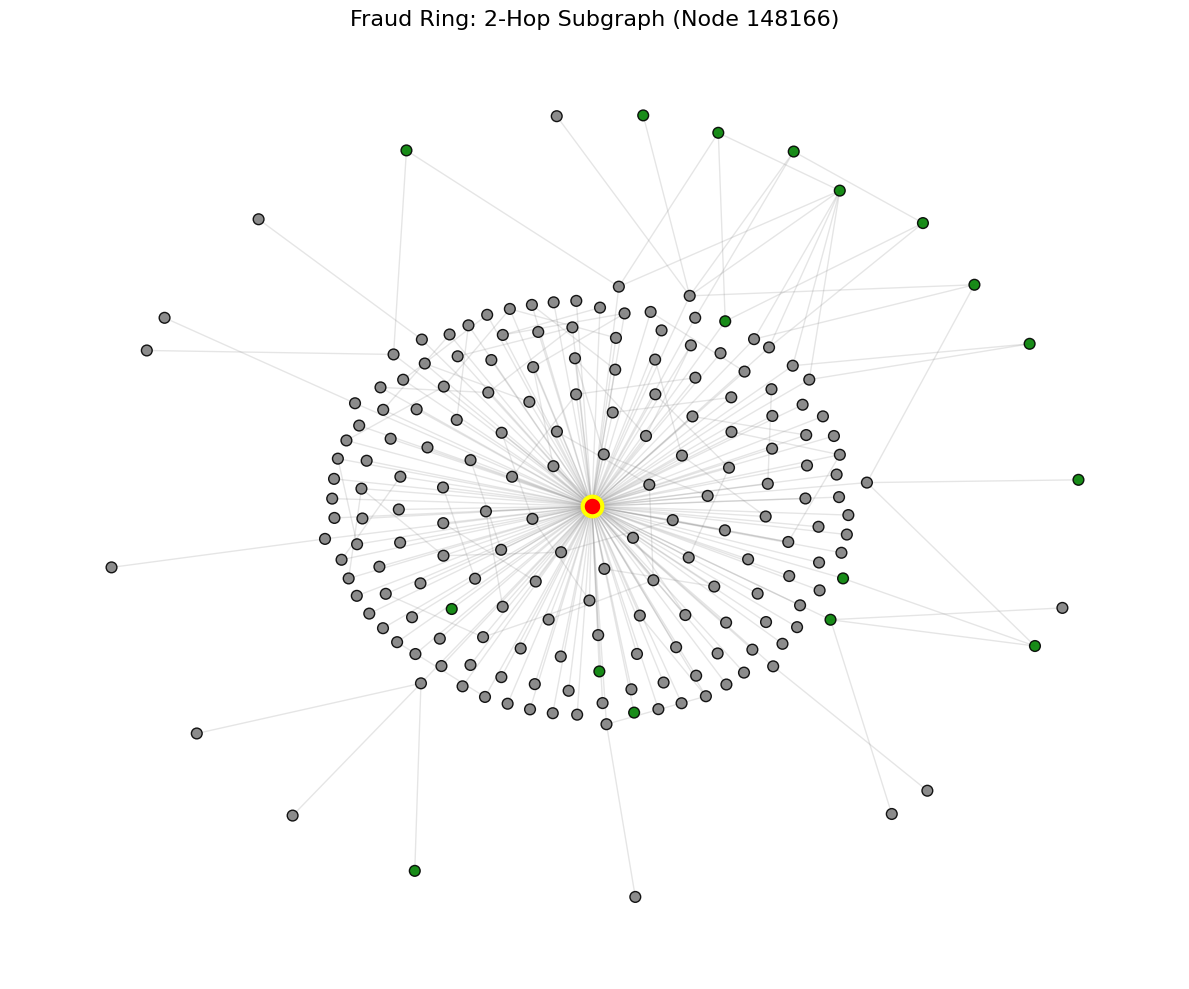

In [20]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx, k_hop_subgraph, degree, to_undirected

# 1. Convert edges to undirected to catch both incoming and outgoing money
undirected_edge_index = to_undirected(data.edge_index)

# 2. Find all illicit nodes
illicit_nodes = (data.y == 1).nonzero(as_tuple=True)[0]

# 3. Calculate the degree (number of connections) for all nodes
node_degrees = degree(undirected_edge_index[0], num_nodes=data.num_nodes)

# 4. Find the specific illicit node with the MAXIMUM connections
illicit_degrees = node_degrees[illicit_nodes]
target_node = illicit_nodes[illicit_degrees.argmax()].item()

print(f"Targeting Illicit Node {target_node} with {int(node_degrees[target_node].item())} connections.")

# 5. Extract a 2-hop subgraph around this highly connected target node
subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
    node_idx=target_node, 
    num_hops=2, 
    edge_index=undirected_edge_index, 
    relabel_nodes=True
)

# 6. Create a Data object and convert to NetworkX
sub_data = Data(edge_index=sub_edge_index, num_nodes=subset.size(0))
G = to_networkx(sub_data, to_undirected=True)

# 7. Map colors: Red (Illicit), Green (Licit), Gray (Unknown)
node_colors = []
for node_idx in subset:
    label = data.y[node_idx].item()
    if label == 1:
        node_colors.append('red')
    elif label == 0:
        node_colors.append('green')
    else:
        node_colors.append('gray')

# 8. Plot the graph
plt.figure(figsize=(12, 10))
plt.title(f"Fraud Ring: 2-Hop Subgraph (Node {target_node})", fontsize=16)

# Kamada-Kawai layout often spaces out clusters better than spring layout
pos = nx.kamada_kawai_layout(G) 

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=60, edgecolors='black', alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='gray')

# Highlight the target node with a glowing yellow border
nx.draw_networkx_nodes(G, pos, nodelist=[mapping[0].item()], node_color='red', node_size=200, edgecolors='yellow', linewidths=3)

plt.axis('off')
plt.tight_layout()
plt.show()